In [1]:
import cv2
import os
from moviepy.editor import VideoFileClip
%matplotlib inline
import matplotlib.pyplot as plt

## Object tracking

#### Use laptop's camera

In [2]:
cap = cv2.VideoCapture(0)

# Automatically grab width and height from video feed
# (returns float which we need to convert to integer for later on!)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print(width, height)

640 480


[ WARN:0@0.818] global /croot/opencv-suite_1691620365762/work/modules/videoio/src/cap_gstreamer.cpp (862) isPipelinePlaying OpenCV | GStreamer warning: GStreamer: pipeline have not been created


In [3]:
while True:
    ret, frame = cap.read()
    cv2.imshow('Frame', frame)
    
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

libGL error: MESA-LOADER: failed to open iris: /usr/lib/dri/iris_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)
libGL error: failed to load driver: iris
libGL error: MESA-LOADER: failed to open iris: /usr/lib/dri/iris_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)
libGL error: failed to load driver: iris
libGL error: MESA-LOADER: failed to open swrast: /usr/lib/dri/swrast_dri.so: cannot open shared object file: No such file or directory (search paths /usr/lib/x86_64-linux-gnu/dri:\$${ORIGIN}/dri:/usr/lib/dri, suffix _dri)
libGL error: failed to load driver: swrast


#### Apply tracker

In [4]:
tracker_type = 'KCF'
tracker = cv2.TrackerKCF_create()

cap = cv2.VideoCapture(0)
ret, frame = cap.read()

bbox = cv2.selectROI(frame, False)
cv2.waitKey(0)
cv2.destroyAllWindows()

[ WARN:0@5.459] global /croot/opencv-suite_1691620365762/work/modules/videoio/src/cap_gstreamer.cpp (862) isPipelinePlaying OpenCV | GStreamer warning: GStreamer: pipeline have not been created


In [11]:
bbox

(202, 73, 221, 269)

In [13]:
x0, y0 ,w, h = bbox

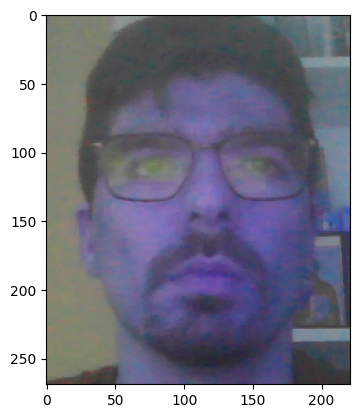

In [14]:
plt.imshow(frame[y0:y0+h, x0:x0+w, :])

In [15]:
ok = tracker.init(frame, bbox)

In [16]:
while True:
    # Read a new frame
    ok, frame = cap.read()
    if not ok:
        break

    # Start timer
    timer = cv2.getTickCount()

    # Update tracker
    ok, bbox = tracker.update(frame)

    # Calculate Frames per second (FPS)
    fps = cv2.getTickFrequency() / (cv2.getTickCount() - timer);

    # Draw bounding box
    if ok:
        # Tracking success
        p1 = (int(bbox[0]), int(bbox[1]))
        p2 = (int(bbox[0] + bbox[2]), int(bbox[1] + bbox[3]))
        cv2.rectangle(frame, p1, p2, (255,0,0), 2, 1)
    else :
        # Tracking failure
        cv2.putText(frame, "Tracking failure detected", (100,80), cv2.FONT_HERSHEY_SIMPLEX, 0.75,(0,0,255),2)

    # Display tracker type on frame
    cv2.putText(frame, tracker_type + " Tracker", (100,20), cv2.FONT_HERSHEY_SIMPLEX, 0.75, (50,170,50),2);

    # Display FPS on frame
    cv2.putText(frame, "FPS : " + str(int(fps)), (100,50), cv2.FONT_HERSHEY_SIMPLEX, 0.75, (50,170,50), 2);

    # Display result
    cv2.imshow("Tracking", frame)

    # Exit if ESC pressed
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break
        
cv2.waitKey(0)
cv2.destroyAllWindows()